# Baseline Hybrid PINN

## Setup of a Damped Pendulum

![Non-Linear ODE for a Damped Pendulum](figures/non-linear_ode.png){width=30%}

Consider a damped pendulum of fixed length $L$ and mass $m$ swinging under gravity $g$. Air resistance introduces a damping force proportional to the angular velocity. The angular displacement from vertical, $\theta(t)$, obeys the following non-linear ODE:

$$
\boxed{\frac{d^2\theta}{dt^2} + \frac{b}{m}\frac{d\theta}{dt} + \frac{g}{L}\sin\bigl(\theta(t)\bigr) = 0}
$$

where $b$ is the damping coefficient. This notebook builds a hybrid PINN that combines ODE-based physics constraints with noisy experimental observations over a 20-second time window ($t \in [0,\,20]$ s).

## Import libraries

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

plt.rcParams["text.usetex"] = True

## PyTorch and GPU Device Selection

PyTorch supports two GPU backends for hardware-accelerated tensor computation (Table 1):

| Backend | API | Hardware |
|---------|-----|----------|
| `cuda` | NVIDIA CUDA | NVIDIA GPUs (GeForce, RTX, Tesla, etc.) |
| `xpu` | Intel oneAPI / SYCL | Intel GPUs (Iris Xe, Arc, Data Center Max) |

**Why can't we use `cuda` for an Intel GPU?** CUDA is NVIDIA's proprietary GPU computing platform. It compiles GPU kernels into NVIDIA's PTX instruction set and communicates through NVIDIA's driver stack. Intel GPUs have a completely different hardware architecture and driver (the Intel compute runtime / Level Zero), so they cannot execute CUDA code, just as an AMD CPU cannot run ARM instructions. Intel's equivalent is the **oneAPI/SYCL** stack, which PyTorch exposes through the `torch.xpu` module.

The cell below sets `gpu_type = "xpu"` and checks `torch.xpu.is_available()` to detect whether the Intel GPU runtime is installed and a compatible Intel GPU is present. If so, all tensors and models created with `.to(device)` will be allocated on the Intel GPU. If no compatible GPU is found, the code falls back to CPU.

In [2]:
import warnings
import torch
import torch.nn as nn

# Suppress Intel Iris Xe "not officially supported" warning
warnings.filterwarnings(
    "ignore",
    message=".*detected GPU.*not officially supported by PyTorch XPU.*")

# Suppress CUDA initialization warning when no compatible NVIDIA driver
# is installed (irrelevant when using XPU or CPU)
warnings.filterwarnings(
    "ignore",
    message=".*CUDA initialization.*")

# Define the GPU type ("cuda" for NVIDIA GPUs, "xpu" for Intel GPUs)
gpu_type = "xpu"

if gpu_type == "cuda":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
elif gpu_type == "xpu":
    device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
else:
    raise ValueError("Invalid GPU type. Use 'cuda' or 'xpu'.")

print(f"Using device: {device}")

Using device: xpu


# Numerical Ground Truth

We first generate the reference solution using `scipy.integrate.odeint`  so we can later compare the PINN against it and sample synthetic "experimental" data from it. Table 2 summarizes the list of physical parameters to solve the second-order ODE equation.

| Parameter | Symbol | Value | Unit |
|-----------|--------|------:|------|
| Gravitational acceleration | $g$ | 9.81 | m/s² |
| Pendulum length | $L$ | 1.0 | m |
| Mass | $m$ | 1.0 | kg |
| Damping coefficient | $b$ | 0.25 | kg/s |
| Initial angle | $\theta_0$ | $\pi/4$ (45°) | rad |
| Initial angular velocity | $\omega_0$ | 0.0 | rad/s |
| Start time | $t_\text{start}$ | 0 | s |
| End time | $t_\text{end}$ | 20 | s |

## ODE integration

`odeint` requires a system of first-order ODEs, but the pendulum equation is second-order. We convert it by introducing the angular velocity $\omega = d\theta/dt$ as a new variable, turning one second-order equation into two first-order equations.

Starting from:

$$\frac{d^2\theta}{dt^2} + \frac{b}{m}\,\frac{d\theta}{dt} + \frac{g}{L}\sin\theta = 0$$

**Step 1:** Define $\omega \equiv d\theta/dt$, so:

$$\frac{d\theta}{dt} = \omega$$

**Step 2:** Since $\omega = d\theta/dt$, we have $d\omega/dt = d^2\theta/dt^2$. Substituting into the original ODE and rearranging for $d\omega/dt$:

$$\frac{d^2\theta}{dt^2} = -\frac{b}{m}\,\frac{d\theta}{dt} - \frac{g}{L}\sin\theta$$

$$\frac{d\omega}{dt} = -\frac{g}{L}\sin\theta - \frac{b}{m}\,\omega$$

The state vector is $[\theta, \omega]$ and `pendulum_system` returns $[d\theta/dt,\; d\omega/dt]$ at each time step. `odeint` integrates this system forward from $[\theta_0, \omega_0]$, giving both the angular displacement $\theta(t)$ and angular velocity $d\theta/dt$ at every time point.

### `odeint` syntax

```python
solution = odeint(func, y0, t, args=(...))
```

| Argument | Description |
|----------|-------------|
| `func` | A callable that returns the derivatives. Signature: `func(y, t, ...)` where `y` is the current state vector and `t` is the current time. |
| `y0` | Initial condition, i.e. the state vector at `t[0]`. For this problem: `[theta0, omega0]`. |
| `t` | 1-D array of time points at which the solution is stored. The solver uses adaptive internal steps but interpolates to report values at these times. |
| `args` | Extra arguments passed through to `func` after `y` and `t`. Here we pass the physical constants `(g, L, b, m)`. |

The returned `solution` is a 2-D array of shape `(len(t), 2)`, where column 0 holds $\theta(t)$ and column 1 holds $\omega(t)$ at each requested time point.

Here, the displacement plot on the left shows an oscillating, but gradually decaying angular displacement over 20 seconds due to the damping effect. With a damping coefficient of 0.25 ($b = 0.25$) and the natural frequency $\omega_n \approx 3.13$ rad/s (period $\approx 2$ s), the pendulum completes roughly 10 oscillations before the amplitude decays to near zero. The velocity plot on the right shows the angular velocity, which oscillates 90° out of phase with displacement (velocity peaks when the displacement crosses zero).

In [4]:
# Physical parameters
g = 9.81
L = 1.0
m = 1.0
b = 0.25

# Initial conditions
# Starting at 45 degrees with zero initial angular velocity
theta0_ground_truth = 45 * np.pi / 180   # 45 degrees in radians
omega0_ground_truth = 0.0

t_start = 0
t_end   = 20
t_range_ode_ground_truth = np.linspace(t_start, t_end, 1000)

# Define the pendulum system of ODEs
def pendulum_system(states, t, g, L, b, m):
    theta, omega = states
    return [omega, -(g / L) * np.sin(theta) - (b / m) * omega]

# Compute the ground truth solution using odeint
solution  = odeint(
    pendulum_system,
    [theta0_ground_truth, omega0_ground_truth],
    t_range_ode_ground_truth,
    args=(g, L, b, m))

# Extract theta and omega from the solution
theta_ground_truth = solution[:, 0]
omega_ground_truth = solution[:, 1]

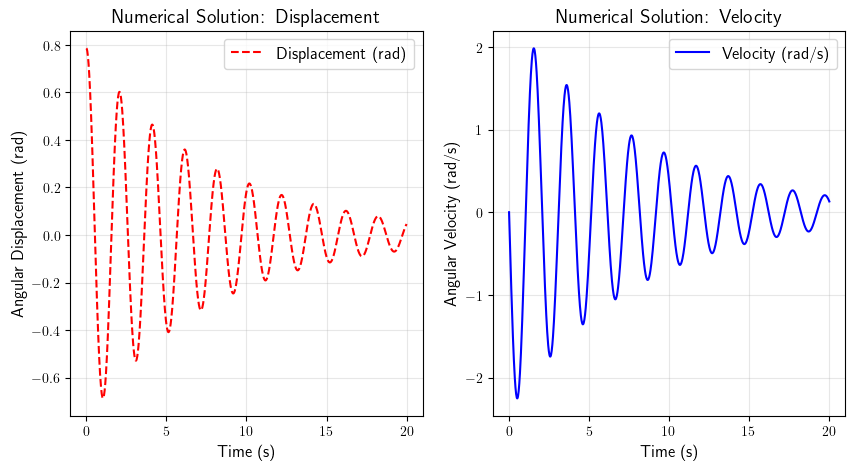

In [5]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 5))
fig.subplots_adjust(hspace=0.3)

#  Displacement plot 
axes[0].plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    linestyle='dashed',
    color='red',
    label=r'Displacement (rad)')
axes[0].set_xlabel('Time (s)', fontsize=12)
axes[0].set_ylabel(r'Angular Displacement (rad)', fontsize=12)
axes[0].set_title(r'Numerical Solution: Displacement', fontsize=14)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

#  Velocity plot 
axes[1].plot(
    t_range_ode_ground_truth,
    omega_ground_truth,
    linestyle='solid',
    color='blue',
    label=r'Velocity (rad/s)')
axes[1].set_xlabel(r'Time (s)', fontsize=12)
axes[1].set_ylabel(r'Angular Velocity (rad/s)', fontsize=12)
axes[1].set_title(r'Numerical Solution: Velocity', fontsize=14)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

# Create the "figures" directory if it doesn't exist
os.makedirs("figures", exist_ok=True)

# Save the figure with high resolution and tight layout
plt.savefig(
    "figures/numerical_solution.png",
    dpi=600,
    bbox_inches='tight')

plt.show()

# Synthetic Experimental Data

In a real application the experimental data would come from sensors, but here we generate it synthetically from the numerical solution so we have a controlled ground truth to validate against.

**Sampling strategy:** 250 time points are drawn uniformly at random from $[0, 20]$ s and sorted into chronological order. Using random (non-uniform) spacing rather than a regular grid mimics real sensor data, where measurements may arrive at irregular intervals. The ODE is then solved at exactly these time points to obtain the "true" displacement values.

**Adding noise:** Each displacement value is perturbed by Gaussian noise with $\sigma = 0.001$ rad ($\approx 0.06°$). This is small enough that the data closely follows the true solution, but large enough to prevent the network from memorizing individual points. The physics loss will help the PINN smooth through this noise rather than fitting it.

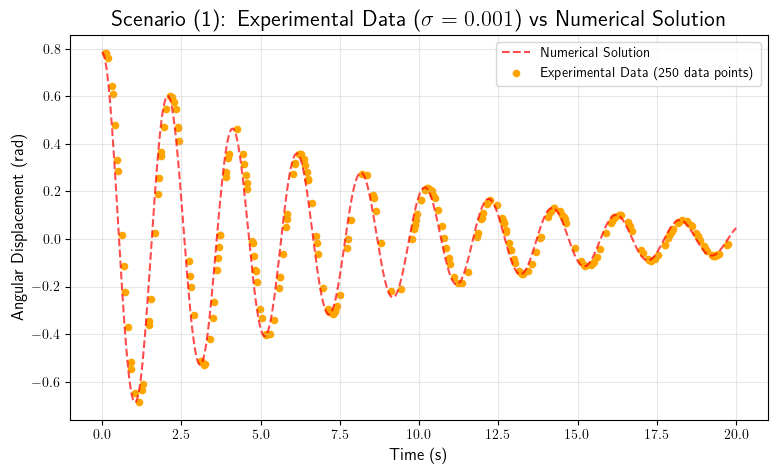

In [6]:
N_exp_points = 250

np.random.seed(42)

# Generate 250 random time points uniformly in [t_start, t_end),
# using the shift-and-scale formula: rand() * (b - a) + a.
# np.sort arranges them in chronological order so the data
# looks like a realistic time series from a sensor.
t_exp_np_clean_data = np.sort(
    np.random.rand(N_exp_points) * (t_end - t_start) + t_start)

# Simulate the pendulum system at these random time points to get the "true" 
# angular displacement values
solution_exp_clean_data = odeint(
    pendulum_system,
    [theta0_ground_truth, omega0_ground_truth],
    t_exp_np_clean_data,
    args=(g, L, b, m))

# Noise standard deviation = 0.001 rad (small, realistic sensor noise)
# noise standard deviation (rad)
exp_noise_clean_data = 0.001

# Add realistic noise to the angular displacement data
theta_exp_np_clean_data = (
    solution_exp_clean_data[:, 0] 
    + exp_noise_clean_data * np.random.randn(N_exp_points))

fig, ax = plt.subplots(
    figsize=(9, 5))

ax.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label=r'Numerical Solution',
    alpha=0.7)
ax.scatter(
    t_exp_np_clean_data,
    theta_exp_np_clean_data,
    color='orange',
    s=20,
    label=rf'Experimental Data ({N_exp_points} data points)')

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax.set_title(
    rf"Scenario (1): Experimental Data ($\sigma = {exp_noise_clean_data}$) " 
    + "vs Numerical Solution",
    fontsize=16)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Data Normalization

When we give a neural network input data with very different scales, such as  $t \in [0, 20]$ vs $\theta \in [-0.8, 0.8]$, its weights must compensate for the scale mismatch, which could slow the network training and risk trapping the optimizer  in suboptimal solutions. Data normalization avoids this by transforming all inputs into a common range, for example, to zero mean with unit standard deviation, so that no single feature dominates the gradient updates. In this example for our damped pendulum ODE problem, we applied time and displacement normalization as described below.

### Time normalization ($t \to \tilde{t}$)

Time normalization maps the raw experimental time points from $[0, 20]$ to $[-1, +1]$ using:


$$\tilde{t} = \frac{2(t - t_\text{min})}{t_\text{max} - t_\text{min}} - 1$$


For $t_\text{min} = 0$ and $t_\text{max} = 20$, the normalization has transformed the input time range to $[-1, +1]$, where the midpoint is mapped to zero. 

| Raw time $t$ (s) | Normalized time $\tilde{t}$ | Interpretation |
|------------------:|----------------------------:|----------------|
| 0 | $-1$ | Start of the time window |
| 5 | $-0.5$ | Quarter point |
| 10 | $0$ | Midpoint |
| 15 | $+0.5$ | Three-quarter point |
| 20 | $+1$ | End of the time window |


If we feed the neural network with raw time values as large as 20 seconds, we could potentially push the first layer's pre-activations into the flat tails of the Tanh curve, where the function is nearly constant and its gradient is close to zero. As a result, the weight updates in this regime could be very small, which could stall the network training and convergence. 


It is also important to note that the physics loss depends on derivatives such as $d\theta/dt$ and $d^2\theta/dt^2$ computed via automatic differentiation. Because these derivatives inherit the input scale, unnormalized time values could inflate some ODE residual terms to have orders of magnitude larger than others. This scale imbalance could therefore make the residual numerically ill-conditioned, where the optimizer would focus on the dominant loss terms while neglecting the rest. By rescaling the input time range to [-1, 1], we confine the pre-activations to the steep central region of Tanh curve, where the gradients are strongest, to ensure reliable and faster convergence.


### Displacement normalization ($\theta \to \tilde{\theta}$)

Displacement normalization standardizes the noisy experimental $\theta$ values to zero mean and unit standard deviation:


$$\tilde{\theta} = \frac{\theta - \mu_\theta}{\sigma_\theta}$$


where $\mu_\theta$ and $\sigma_\theta$ are computed from the experimental data.

**Why is displacement normalization important?** As the pendulum's oscillation is not symmetric about zero and its amplitude depends on the initial angle and the damping effect, the raw displacement values also carry a specific offset and spread. If the network must reproduce these values directly, its randomly initialized output layers would start far from the target, where early training will be spent on capturing these offsets instead of learning the oscillatory dynamics. By applying $Z$-score normalization, we help keep the network's initial predictions close to the normalized targets, and the squared data loss is on the order of 1 (i.e. $\|\tilde{\theta}_\text{pred} - \tilde{\theta}_\text{exp}\|^2 \approx \mathcal{O}(1)$).


Nevertheless, as the residual of the PINN is computed in physical units (radians), the predicted standardized angular displacement from the PINN network must be denormalized. This is necessary for two reasons:


1. We need physical units to compute the ODE residual because the ODE equation has parameters and constants such as $g$ in [m/s²], $L$ in [m], $m$ in [kg], and $b$ in [kg/s]. If we would substitute the standardized and unitless $\tilde{\theta}$ into the ODE equation and its derivative terms, we would produce a residual that no longer represents the actual pendulum equation. Therefore, we must first map the network's predicted outputs from the normalized space back into the physical space via $\theta = \tilde{\theta}\,\sigma_\theta + \mu_\theta$ so that every term in the ODE has consistent units (rad/s²).


2. Because the network operates on $\tilde{\theta}(\tilde{t})$ and automatic differentiation produces $d\tilde{\theta}/d\tilde{t}$ (not the physical $d{\theta}/dt$), converting between the normalized and physical derivatives requires chain-rule scaling factors that depend on the normalization constants. Without denormalization, we would use the incorrectly scaled derivatives in  the ODE residual, where the physics loss would penalize a quantity that does not correspond to the actual pendulum equation.


This means that the PINN network is trained in normalized space for numerical stability reasons, but the governing equation is defined in the physical space due to physical units required in the ODE equation. Denormalization helps bridging the two different spaces so that we can achieve numerical stability to train the neural network while enforcing the correct physics through the ODE residuals.

In [ ]:
# ----------------------------------------------------------------------------
# Time normalization
# Time normalization constants
t_min = t_start
t_max = t_end
dt    = t_max - t_min

# Normalize time to [-1, +1]
# Formula: t_norm = 2*(t - t_min)/dt - 1
# t=0 → -1,  t=10 → 0,  t=20 → +1
time_exp_norm_np     = 2 * (t_exp_np_clean_data - t_min) / dt - 1.0

# Convert to PyTorch tensors
time_exp_norm     = torch.from_numpy(
    time_exp_norm_np).float().view(-1, 1).to(device)

# Sanity check: time_exp_norm should be in [-1, +1]
print("time_exp_norm range:") 
print(f"[{time_exp_norm.min():.3f}, {time_exp_norm.max():.3f}]")
print("-"*79)

# ----------------------------------------------------------------------------
# Displacement normalization constants (from synthetic experimental data)
theta_mean_clean_data = np.mean(theta_exp_np_clean_data)

# Use sample standard deviation (ddof=1) for an unbiased estimate of 
# population std
theta_std_clean_data  = np.std(theta_exp_np_clean_data, ddof=1)

# Standardize displacement (zero mean, unit std)
# Formula: theta_norm = (theta - mean) / std
theta_exp_norm_np = (
    theta_exp_np_clean_data - theta_mean_clean_data) / theta_std_clean_data

theta_exp_norm = torch.from_numpy(
    theta_exp_norm_np).float().view(-1, 1).to(device)

# Sanity check: theta_exp_norm should have mean ~0 and std ~1
print("Displacement theta_exp_norm mean:") 
print(f"{theta_exp_norm.mean():.4f}")
print("-"*79)
print("Displacement theta_exp_norm std:") 
print(f"{theta_exp_norm.std():.4f}")

time_exp_norm range:
[-0.990, 0.974]
-------------------------------------------------------------------------------
Displacement theta_exp_norm mean:
0.0000
-------------------------------------------------------------------------------
Displacement theta_exp_norm std:
1.0020


# Baseline PINN

## Neural network architecture

`FullyConnectedNN` is a simple fully connected (dense) feed-forward network. It takes a single **normalized time** input $\tilde{t} \in [-1, +1]$ and returns a single **normalized displacement** prediction $\tilde{\theta}$. The architecture consists of three groups of layers:

| Component | Abbreviation                       | Description                                                                                                                                                                      |
| --------- | ---------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `fcs`     | **f**ully **c**onnected **s**tart  | **Input layer** (`Linear(1, 64) + Tanh`): maps the 1-D normalized time to 64 hidden units, followed by a `Tanh` activation to introduce nonlinearity.                            |
| `fch`     | **f**ully **c**onnected **h**idden | **Hidden layers** (2 × `Linear(64, 64) + Tanh`): two additional dense layers (`N_LAYERS - 1 = 2`) with `Tanh` activations that progressively refine the internal representation. |
| `fce`     | **f**ully **c**onnected **e**nd    | **Output layer** (`Linear(64, 1)`): maps the 64 hidden units back to a single scalar (the normalized displacement). No activation is applied here.

In total, the network has **3 weight layers** (1 input + 2 hidden) and uses the hyperbolic tangent ($\tanh$) activation throughout. `Tanh` is a common choice for PINNs because it is infinitely differentiable, which is essential since the physics loss requires computing $d\theta/dt$ and $d^2\theta/dt^2$ via automatic differentiation through the network.

## Normalization helpers

- **`normalize_time_input(t_tensor)`** maps physical time $t \in [t_\text{min},\, t_\text{max}]$ to $\tilde{t} \in [-1, +1]$ using $\tilde{t} = 2(t - t_\text{min})/(t_\text{max} - t_\text{min}) - 1$. This ensures all inputs are in a narrow, symmetric range where gradient-based optimization is most stable.
- **`denormalize_theta(theta_tensor)`** reverses the standardization $\tilde{\theta} \mapsto \theta = \tilde{\theta}\,\sigma_\theta + \mu_\theta$ so that the network's output can be compared against the ODE in physical units (radians). The ODE is written in physical units ($d^2\theta/dt^2$ in rad/s², $d\theta/dt$ in rad/s, $t$ in s). Differentiating in normalized space would introduce chain-rule factors of $\sigma_\theta$ and $\Delta t / 2$ that change the residual's numerical scale, making the physical coefficients ($b/m$, $g/L$) no longer match their true values. Denormalizing first ensures the ODE is enforced exactly as written.

## Training configuration

| Setting | Value | Purpose |
|---------|-------|---------|
| Collocation points | 1,000 uniform in $[0, 20]$ s | Physics residual evaluation; `requires_grad=True` enables autograd for $d\theta/dt$ and $d^2\theta/dt^2$ |
| Initial condition | $t = 0$ | Initial-condition loss ($\theta_0 = 0.785$ rad, $\dot\theta_0 = 0$) |
| Experimental points | 250 data points | Synthetic experimental data |
| $\lambda_\text{IC}$ | 1 | Weight for initial-condition loss |
| $\lambda_\text{phys}$ | 1 | Weight for ODE residual loss |
| $\lambda_\text{data}$ | 1 | Weight for data-fidelity loss |
| Optimizer | Adam, $\text{lr} = 10^{-3}$ | Adaptive first-order optimizer |
| LR scheduler | `StepLR`, halve every 5,000 epochs | Fine-tune in the second half of training. Early in training a larger learning rate lets the network take big steps and rapidly reduce the loss from its random initialization. Later, those same large steps might overshoot minima and cause the loss to oscillate. Halving the rate at epoch 5,000 slows updates so the optimizer can fine-tune the solution more precisely, often visible as a kink in the loss curve where convergence briefly accelerates after the reduction. |
| Epochs | 10,000 | Total training iterations |

In [8]:
class FullyConnectedNN(nn.Module):
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()

        # Use Tanh activations
        activation = nn.Tanh
        
        # First layer: input to hidden layer (with activation)
        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation())
        
        # Hidden layers with -1 layer because the first layer 
        # is already defined
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation())
            for _ in range(N_LAYERS - 1)])
        
        # Output layer: hidden to output (no activation)
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

# ---------------------------------------------------------------------------
# Normalization helpers
# Normalize time to [-1, +1] for better training stability
def normalize_time_input(t_tensor):
    return 2.0 * (t_tensor - t_min) / dt - 1.0

# Denormalize the predicted theta back to physical units (radians)
def denormalize_theta(
    theta_tensor,
    theta_mean,
    theta_std):
    
    return theta_tensor * theta_std + theta_mean

# ---------------------------------------------------------------------------

In [9]:
# PINN hyperparameters
n_input = 1
n_output = 1
n_hidden = 64
n_layers = 3
epochs_clean_data = 10000
learning_rate = 1e-3
lambda_boundary = 1
lambda_physics = 1
lambda_data = 1

# Create the PINN model and move it to the appropriate device (CPU or GPU)
baseline_pinn = FullyConnectedNN(
    n_input,
    n_output,
    n_hidden,
    n_layers).to(device)

# ---------------------------------------------------------------------------
# Training points
# Initial condition point: t=0, theta=theta0 (normalized)
t_ic = torch.tensor(
    [[0.0]],
    device=device,
    requires_grad=True)

# Create collocation points for physics loss: 1000 points uniformly in 
# [t_start, t_end]
# t_start = 0, t_end = 20
N_phys = 1000
t_phys_clean_data = torch.linspace(
    t_start,
    t_end,
    N_phys,
    device=device).view(-1, 1)
t_phys_clean_data.requires_grad_(True)

# ----------------------------------------------------------------------------
# Check PINN parameters
for index, p in enumerate(baseline_pinn.parameters(), 1):
    print(f"Layer {index}: {p.numel()} parameters with shape: {p.shape}")

print("-" * 79)
print("Total parameters in the network:")
print(sum(p.numel() for p in baseline_pinn.parameters()))

Layer 1: 64 parameters with shape: torch.Size([64, 1])
Layer 2: 64 parameters with shape: torch.Size([64])
Layer 3: 4096 parameters with shape: torch.Size([64, 64])
Layer 4: 64 parameters with shape: torch.Size([64])
Layer 5: 4096 parameters with shape: torch.Size([64, 64])
Layer 6: 64 parameters with shape: torch.Size([64])
Layer 7: 64 parameters with shape: torch.Size([1, 64])
Layer 8: 1 parameters with shape: torch.Size([1])
-------------------------------------------------------------------------------
Total parameters in the network:
8513


# Baseline PINN Training Loop

Each epoch executes four parts, then updates the network weights:

## Part 1: Initial Condition (IC) loss in the physical space

1. Normalize the initial time at $t = 0$ and pass it through the network to get $\tilde{\theta}(0)$.
2. Denormalize the output back to physical units: $\theta(0)$.
3. Compute $d\theta/dt$ at $t = 0$ using `torch.autograd.grad` with `create_graph=True` (so second-order gradients remain available for backpropagation).
4. Penalize deviations from the known initial conditions:

$$\mathcal{L}_\text{IC} = \bigl(\theta(0) - \theta_0\bigr)^2 + \left(\frac{d\theta}{dt}\bigg|_{t=0} - \omega_0\right)^2$$

## Part 2: Physics (ODE residual) loss in the physical space

1. Normalize the 1,000 collocation times and forward-pass them through the network.
2. Denormalize the predicted $\theta$ to physical units.
3. Compute the first derivative $d\theta/dt$ and second derivative $d^2\theta/dt^2$ via two successive calls to `torch.autograd.grad`. Both use `create_graph=True` so the computational graph extends through the derivatives, allowing the total loss to backpropagate through the physics residual.
4. Evaluate the ODE residual in physical space:

$$r = \frac{d^2\theta}{dt^2} + \frac{b}{m}\,\frac{d\theta}{dt} + \frac{g}{L}\sin\theta$$

$$\mathcal{L}_\text{phys} = \text{mean}(r^2)$$

## Part 3: Data loss in the normalized space

1. Pass the pre-normalized experimental times directly through the network to get normalized predictions.
2. Compare against the normalized experimental displacements:

$$\mathcal{L}_\text{data} = \text{mean}\!\bigl(\tilde{\theta}_\text{pred} - \tilde{\theta}_\text{exp}\bigr)^2$$

This is computed in normalized space (not physical space) so that the data loss magnitude is comparable to the other loss terms without additional scaling.

::: {.callout-note}
## Why physical space for IC/physics but normalized space for data?

The **IC loss** and **physics loss** must be evaluated in physical space because they enforce constraints that are defined in physical units. The initial conditions are specified as $\theta_0 = 0.785$ rad and $\omega_0 = 0$ rad/s, and the ODE coefficients $b/m$ and $g/L$ have fixed physical values. Computing these losses in normalized space would require rewriting the ODE with extra chain-rule factors ($\sigma_\theta$, $\Delta t / 2$) and converting the initial conditions into normalized units, adding complexity for no benefit.

The **data loss**, by contrast, is a simple point-wise comparison between the network's prediction and the experimental measurements. It has no physical equation to satisfy, so there is no requirement to work in any particular unit system. Computing it in normalized space (where both the prediction and the target have zero mean and unit standard deviation) keeps its magnitude naturally $\mathcal{O}(1)$, which is comparable to the IC and physics losses. If the data loss were computed in physical space instead, the raw displacement values (which are small fractions of a radian) would produce a much smaller squared error, and the data term would be underweighted relative to the other losses unless $\lambda_\text{data}$ were increased to compensate.
:::

## Part 4: Total Loss and Weight Update

$$\mathcal{L}_\text{total} = \lambda_\text{IC}\,\mathcal{L}_\text{IC} + \lambda_\text{phys}\,\mathcal{L}_\text{phys} + \lambda_\text{data}\,\mathcal{L}_\text{data}$$

1. `total_loss.backward()` computes gradients of the total loss with respect to all network parameters.
2. `optimizer.step()` updates the weights using Adam.
3. `scheduler.step()` checks whether it is time to halve the learning rate (at epoch 5,000).

In [10]:
# Set random seed for reproducibility
torch.random.manual_seed(42)

# ---------------------------------------------------------------------------
# Define optimizer and LR scheduler
# Create the optimizer using Adam algorithm
optimizer = torch.optim.Adam(
    baseline_pinn.parameters(),
    lr=learning_rate)

# LR scheduler: halve the learning rate every 5000 epochs
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5000,
    gamma=0.5)

# ---------------------------------------------------------------------------
# Training loop

total_loss_history_clean_data = []
ic_loss_history_clean_data = []
physics_loss_history_clean_data = []
data_loss_history_clean_data = []

start_time_training = time.time()

for i in (range(epochs_clean_data + 1)):

    # Reset the gradients
    optimizer.zero_grad()

    # ------------------------------------------------------------------------
    # Part 1: Initial Condition Loss
    t_ic_norm     = normalize_time_input(t_ic)
    theta_ic_norm = baseline_pinn(t_ic_norm)
    theta_ic      = denormalize_theta(
        theta_ic_norm,
        theta_mean_clean_data,
        theta_std_clean_data)
    dtheta_dt_ic  = torch.autograd.grad(
        outputs=theta_ic,
        inputs=t_ic,
        grad_outputs=torch.ones_like(theta_ic),
        create_graph=True)[0]

    # ------------------------------------------------------------------------
    # Squared error between predicted angle at t=0 and theta0=0.785 rad
    # Note: theta_ic is already in physical space after denormalization
    loss_theta_ic  = torch.mean((theta_ic - theta0_ground_truth) ** 2)

    # Squared error between predicted velocity at t=0 and omega0=0
    loss_dtheta_ic = torch.mean((dtheta_dt_ic - omega0_ground_truth) ** 2)

    total_loss_ic = loss_theta_ic + loss_dtheta_ic
    ic_loss_history_clean_data.append(total_loss_ic.item())

    # ------------------------------------------------------------------------
    # Part 2: Physics (ODE Residual) Loss
    t_phys_norm      = normalize_time_input(t_phys_clean_data)
    theta_phys_norm  = baseline_pinn(t_phys_norm)
    theta_phys       = denormalize_theta(
        theta_phys_norm,
        theta_mean_clean_data,
        theta_std_clean_data)

    dtheta_dt_phys   = torch.autograd.grad(
        outputs=theta_phys,
        inputs=t_phys_clean_data,
        grad_outputs=torch.ones_like(theta_phys),
        create_graph=True)[0]
    d2theta_dt2_phys = torch.autograd.grad(
        outputs=dtheta_dt_phys,
        inputs=t_phys_clean_data,
        grad_outputs=torch.ones_like(dtheta_dt_phys),
        create_graph=True)[0]

    # ODE residual in the physical space:
    # d²θ/dt² + (b/m)·dθ/dt + cp·sin(θ)
    # Derivatives are w.r.t. physical time t, and 
    # theta is in physical units (rad)
    r_physics    = (
        d2theta_dt2_phys 
        + (b/m)*dtheta_dt_phys 
        + (g/L)*torch.sin(theta_phys)
    )

    loss_physics = torch.mean(r_physics ** 2)
    physics_loss_history_clean_data.append(loss_physics.item())

    # ------------------------------------------------------------------------
    # Part 3: Data Loss (in normalized space)
    # t_exp_norm is already normalized; baseline_pinn outputs normalized 
    # theta directly
    theta_data_norm = baseline_pinn(time_exp_norm)

    # Squared error between normalized prediction and normalized exp data
    # Both are in units of std devs, no unit conversion is needed
    loss_data = torch.mean((theta_data_norm - theta_exp_norm) ** 2)
    data_loss_history_clean_data.append(loss_data.item())

    # ------------------------------------------------------------------------
    # Part 4: Total Loss
    total_loss = (
        lambda_boundary * total_loss_ic 
        + lambda_physics * loss_physics 
        + lambda_data * loss_data)

    total_loss.backward()
    optimizer.step()
    scheduler.step()
    total_loss_history_clean_data.append(total_loss.item())

end_time_training = time.time()
training_duration = end_time_training - start_time_training

print("Training complete. " 
    + f"Final loss: {total_loss_history_clean_data[-1]:.6f}")
print(f"Total training time: {training_duration:.4f} seconds")

Training complete. Final loss: 0.054745
Total training time: 86.4573 seconds


# Evaluation and Visualization

## Inference

1. Create 300 evenly spaced test points over $[0, 20]$ s and normalize them to $[-1, +1]$.
2. Run the trained PINN inside `torch.no_grad()` to disable gradient tracking (no training is happening, so we save memory and computation).
3. Denormalize the network output back to physical displacement (rad) and convert the tensors to NumPy arrays for plotting.

## Plot 1: Displacement prediction

Overlays five elements on one figure:

- **PINN prediction** (black solid): the trained network's output at 300 test points.
- **Numerical solution** (red dashed): the `odeint` ground truth for comparison.
- **Physics collocation points** (gray dots at $\theta = 0$): shows where the ODE residual was enforced during training. Plotted at zero displacement just to indicate their time locations.
- **Experimental data** (black scatter): the 250 noisy observations the network was trained to fit.
- **Boundary point** (red dot at $t = 0$, $\theta = 0.785$): the initial condition anchor.

If training succeeded, the black curve should closely track the red dashed curve across all 20 seconds.

## Plot 2: Training loss

Plots the total loss on a log scale over all 10,000 epochs. The orange vertical line marks epoch 5,000 where the learning rate was halved. A visible kink or acceleration in the loss curve at this point confirms the scheduler is working as intended.

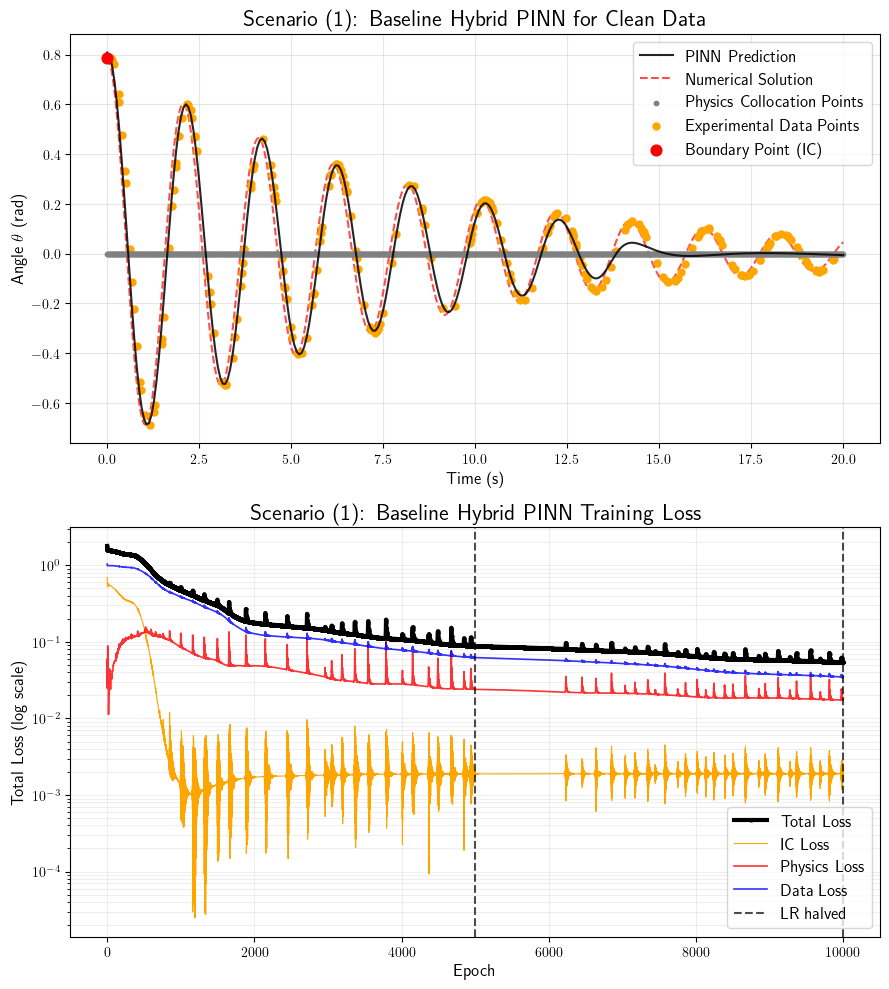

In [11]:
# Evaluate PINN over test points
t_pred_clean_data      = torch.linspace(
    t_start, t_end, 300, device=device).view(-1, 1)
t_pred_norm_clean_data = normalize_time_input(t_pred_clean_data)

# Use torch.no_grad() to avoid tracking gradients during inference, 
# since we only want the predicted values and not the gradients here.
with torch.no_grad():
    theta_pred_norm_clean_data = baseline_pinn(t_pred_norm_clean_data)
    theta_pred_clean_data      = denormalize_theta(
        theta_pred_norm_clean_data,
        theta_mean_clean_data,
        theta_std_clean_data)

# Convert to NumPy for plotting
t_pred_np_clean_data     = t_pred_clean_data[:, 0].detach().cpu().numpy()
theta_pred_np_clean_data = theta_pred_clean_data[:, 0].detach().cpu().numpy()

# ----------------------------------------------------------------------------
# Plot 1: PINN prediction vs numerical solution
fig, axes = plt.subplots(2, 1, figsize=(9, 10))


ax1 = axes[0]

# Plot the PINN prediction
ax1.plot(
    t_pred_np_clean_data,
    theta_pred_np_clean_data,
    color='black',
    label='PINN Prediction',
    alpha=0.85,
    zorder=4)

# Plot the original numerical solution for reference
ax1.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)

# Plot the physics collocation points and experimental data points
# Use the original t_phys tensor to get the collocation points, and 
# convert to NumPy for plotting
t_phys_np_clean_data = t_phys_clean_data[:, 0].detach().cpu().numpy()

ax1.scatter(
    t_phys_np_clean_data,
    np.zeros_like(t_phys_np_clean_data),
    color='gray',
    s=10,
    label='Physics Collocation Points',
    zorder=3)

# Plot the experimental data points (with noise)
ax1.scatter(
    t_exp_np_clean_data,
    theta_exp_np_clean_data,
    color='orange',
    s=25,
    label='Experimental Data Points',
    zorder=2)

# Plot the boundary point (initial condition)
ax1.scatter(
    [0], [theta0_ground_truth],
    color='red', s=60,
    zorder=5,
    label='Boundary Point (IC)')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel(r'Angle $\theta$ (rad)', fontsize=12)
ax1.set_title(
    'Scenario (1): Baseline Hybrid PINN for Clean Data',
    fontsize=16)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Plot 2: Training Loss
ax2 = axes[1]
ax2.plot(
    total_loss_history_clean_data,
    marker='o',
    markersize=2,
    color='black',
    linewidth=3,
    label="Total Loss"
    )
ax2.plot(
    ic_loss_history_clean_data,
    color='orange',
    linewidth=0.8,
    label="IC Loss")
ax2.plot(
    physics_loss_history_clean_data,
    color='red',
    linewidth=1.2,
    alpha=0.8,
    label="Physics Loss")
ax2.plot(
    data_loss_history_clean_data,
    color='blue',
    linewidth=1.2,
    alpha=0.8,
    label="Data Loss")

# Add vertical lines to indicate learning rate halving points
for ep in range(5000, epochs_clean_data + 1, 5000):
    ax2.axvline(
        x=ep,
        color='black',
        linestyle='--',
        alpha=0.7,
        label='LR halved' if ep == 5000 else None)

ax2.set_yscale('log')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Total Loss (log scale)', fontsize=12)
ax2.set_title(
    'Scenario (1): Baseline Hybrid PINN Training Loss',
    fontsize=16)
ax2.legend(fontsize=12)
ax2.grid(True, which='both', linestyle='-', alpha=0.2)
plt.tight_layout()
plt.show()

# Scenario (2): Test Baseline PINN with Noisy Measurements

The previous PINN was trained with very clean data ($\sigma = 0.001$ rad). In this section we increase the noise to $\sigma = 0.1$ rad (two orders of magnitude higher) and examine what changes to the PINN configuration are needed.

## Comparison of Scenario 1 and Scenario 2

| Setting | Scenario 1 (Clean) | Scenario 2 (Noisy) | Comments |
|---|---|---|---|
| **Data** | - | - | - |
| Experimental points | 250 | 250 | Same coverage; only noise changes |
| Noise $\sigma$ | 0.001 rad | **0.1 rad** | 100x larger noise to stress-test robustness |
| **Loss weights** | - | - | - |
| $\lambda_\text{IC}$ | 1 | **5** | Higher IC weight anchors the initial condition more strongly against noisy gradients |
| $\lambda_\text{phys}$ | 1 | **10** | 10x physics weight forces the ODE to strongly dominate noisy data |
| $\lambda_\text{data}$ | 1 | 1 | Keep $\lambda_\text{data}$ at 1 while increasing $\lambda_\text{phys}$ and $\lambda_\text{IC}$ in the noisy data scenario |
| **Training** | - | - | - |
| Epochs | 10,000 | **80,000** | Conflicting data/physics gradients slow convergence under noise |
| LR schedule | Halve every 5,000 | Halve every **20,000** | Proportionally delayed to match the longer training |
| Collocation points | 1,000 | **2,000** | Denser ODE supervision helps physics compete with noisy data |
| **Architecture** | - | - | - |
| Hidden units | 64 | 64 | Same width |
| Hidden layers | 3 | **4** | Extra layer gives more capacity to separate signal from noise |
| Learning rate | $10^{-3}$ | $10^{-3}$ | Same initial rate |

Here we adjust **only hyperparameters** (the `FullyConnectedNN` architecture is unchanged to give the baseline its best chance before moving to Fourier features and curriculum training).

### Why this still won't fully succeed

::: {.callout-note}
## Limitations of hyperparameter tuning alone

Even with these improvements, the baseline PINN is expected to capture the **initial oscillations** reasonably well but **degrade at later times**. This is because:

- The `Tanh` network suffers from **spectral bias** as it learns low-frequency trends quickly but struggles to maintain high-frequency oscillatory accuracy over the full 20 s window.
- Without **curriculum training**, the optimizer must satisfy the ODE across all 20 seconds simultaneously, including the late-time region where noise dominates the signal.
- Without **causal weighting** or **data-weight decay**, the network has no mechanism to prioritize early (high-SNR) data over late (low-SNR) data.

These structural limitations motivate the Fourier feature PINN with curriculum training in the next notebook.
:::

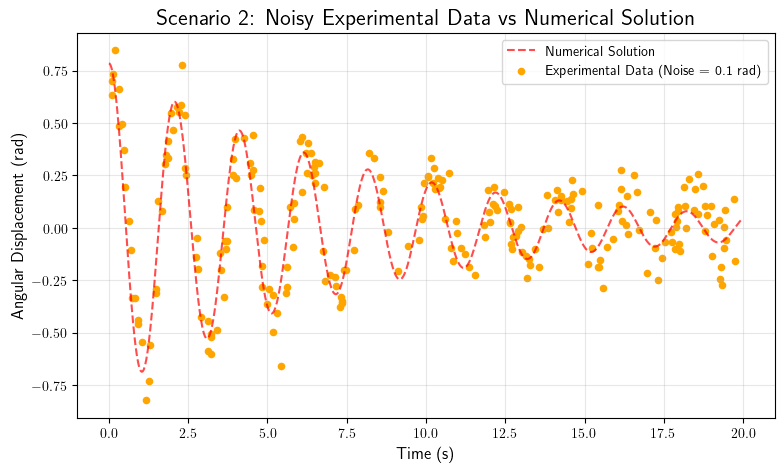

In [12]:
N_exp_points_noisy = 250

np.random.seed(42)

# Generate 250 random time points uniformly in [t_start, t_end),
t_exp_np_noisy = np.sort(
    np.random.rand(N_exp_points_noisy) * (t_end - t_start) + t_start)

# Simulate the pendulum system at these random time points to get the "true" 
# angular displacement values
solution_exp = odeint(
    pendulum_system,
    [theta0_ground_truth, omega0_ground_truth],
    t_exp_np_noisy,
    args=(g, L, b, m))


# Increase noise from 0.001 rad to 0.1 rad for 
# a more challenging scenario
exp_noise_noisy_data = 0.1

theta_exp_np_noisy = (
    solution_exp[:, 0] 
    + exp_noise_noisy_data * np.random.randn(N_exp_points_noisy))

fig, ax = plt.subplots(
    figsize=(9, 5))

ax.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)
ax.scatter(
    t_exp_np_noisy,
    theta_exp_np_noisy,
    color='orange',
    s=20,
    label=f'Experimental Data (Noise = 0.1 rad)')

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax.set_title(
    'Scenario 2: Noisy Experimental Data vs Numerical Solution',
    fontsize=16)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ----------------------------------------------------------------------------
# Time normalization
# Time normalization constants
t_min = t_start
t_max = t_end
dt    = t_max - t_min

# Normalize time to [-1, +1]
# Formula: t_norm = 2*(t - t_min)/dt - 1
# t=0 → -1,  t=10 → 0,  t=20 → +1
time_exp_norm_np_noisy     = 2 * (t_exp_np_noisy - t_min) / dt - 1.0

# Convert to PyTorch tensors
time_exp_norm_noisy = torch.from_numpy(
    time_exp_norm_np_noisy).float().view(-1, 1).to(device)

# Sanity check: time_exp_norm_noisy should be in [-1, +1]
print("time_exp_norm_noisy range:") 
print(f"[{time_exp_norm_noisy.min():.3f}, {time_exp_norm_noisy.max():.3f}]")
print("-"*79)

# ----------------------------------------------------------------------------
# Displacement normalization constants (from synthetic experimental data)
theta_mean_noisy = np.mean(theta_exp_np_noisy)
theta_std_noisy  = np.std(theta_exp_np_noisy, ddof=1)

# Standardize displacement (zero mean, unit std)
# Formula: theta_norm = (theta - mean) / std
theta_exp_norm_np_noisy = (theta_exp_np_noisy 
    - theta_mean_noisy) / theta_std_noisy

theta_exp_norm_noisy = torch.from_numpy(
    theta_exp_norm_np_noisy).float().view(-1, 1).to(device)

# Sanity check: theta_exp_norm_noisy should have mean ~0 and std ~1
print("Displacement theta_exp_norm_noisy mean:") 
print(f"{theta_exp_norm_noisy.mean():.4f}")
print("-"*79)
print("Displacement theta_exp_norm_noisy std:") 
print(f"{theta_exp_norm_noisy.std():.4f}")

time_exp_norm_noisy range:
[-0.990, 0.974]
-------------------------------------------------------------------------------
Displacement theta_exp_norm_noisy mean:
-0.0000
-------------------------------------------------------------------------------
Displacement theta_exp_norm_noisy std:
1.0020


In [14]:
# Set random seed for reproducibility
torch.random.manual_seed(42)

# ---------------------------------------------------------------------------
# PINN hyperparameters
n_input = 1
n_output = 1
n_hidden = 64
n_layers = 4
epochs_noisy_data = 80000
learning_rate = 1e-3
lambda_boundary = 5
lambda_physics = 10
lambda_data = 1

# Create the baseline PINN model for the noisy data scenario
baseline_pinn_noisy_data = FullyConnectedNN(
    n_input, n_output, n_hidden, n_layers).to(device)

# ---------------------------------------------------------------------------
# Training points
# Initial condition point: t=0, theta=theta0 (normalized)
t_ic = torch.tensor(
    [[0.0]],
    device=device,
    requires_grad=True)

# Create collocation points for physics loss: 2000 points uniformly in 
# [t_start, t_end]
# t_start = 0, t_end   = 20
N_phys = 2000
t_phys_noisy_data = torch.linspace(
    t_start,
    t_end,
    N_phys,
    device=device).view(-1, 1)
t_phys_noisy_data.requires_grad_(True)

# ----------------------------------------------------------------------------
# Check PINN parameters
for index, p in enumerate(baseline_pinn_noisy_data.parameters(), 1):
    print(f"Layer {index}: {p.numel()} parameters with shape: {p.shape}")

print("-" * 79)
print("Total parameters in the network:")
print(sum(p.numel() for p in baseline_pinn_noisy_data.parameters()))

Layer 1: 64 parameters with shape: torch.Size([64, 1])
Layer 2: 64 parameters with shape: torch.Size([64])
Layer 3: 4096 parameters with shape: torch.Size([64, 64])
Layer 4: 64 parameters with shape: torch.Size([64])
Layer 5: 4096 parameters with shape: torch.Size([64, 64])
Layer 6: 64 parameters with shape: torch.Size([64])
Layer 7: 4096 parameters with shape: torch.Size([64, 64])
Layer 8: 64 parameters with shape: torch.Size([64])
Layer 9: 64 parameters with shape: torch.Size([1, 64])
Layer 10: 1 parameters with shape: torch.Size([1])
-------------------------------------------------------------------------------
Total parameters in the network:
12673


In [15]:
# Set random seed for reproducibility
torch.random.manual_seed(42)

# ---------------------------------------------------------------------------
# Define optimizer and LR scheduler
# Create the optimizer using Adam algorithm
optimizer = torch.optim.Adam(
    baseline_pinn_noisy_data.parameters(),
    lr=learning_rate)

# LR scheduler: halve the learning rate every 20000 epochs
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=20000,
    gamma=0.5)

# ---------------------------------------------------------------------------
# Training loop

total_loss_history_noisy_data = []
ic_loss_history_noisy_data = []
physics_loss_history_noisy_data = []
data_loss_history_noisy_data = []

start_time_training = time.time()

for i in (range(epochs_noisy_data + 1)):

    # Reset the gradients
    optimizer.zero_grad()

    # ------------------------------------------------------------------------
    # Part 1: Initial Condition Loss
    t_ic_norm     = normalize_time_input(t_ic)
    theta_ic_norm = baseline_pinn_noisy_data(t_ic_norm)
    theta_ic      = denormalize_theta(
        theta_ic_norm,
        theta_mean_noisy,
        theta_std_noisy)
    dtheta_dt_ic  = torch.autograd.grad(
        outputs=theta_ic,
        inputs=t_ic,
        grad_outputs=torch.ones_like(theta_ic),
        create_graph=True)[0]

    # ------------------------------------------------------------------------
    # Squared error between predicted angle at t=0 and theta0=0.785 rad
    # Note: theta_ic is already in physical space after denormalization
    loss_theta_ic  = torch.mean((theta_ic - theta0_ground_truth) ** 2)

    # Squared error between predicted velocity at t=0 and omega0=0
    loss_dtheta_ic = torch.mean((dtheta_dt_ic - omega0_ground_truth) ** 2)

    total_loss_ic = loss_theta_ic + loss_dtheta_ic
    ic_loss_history_noisy_data.append(total_loss_ic.item())

    # ------------------------------------------------------------------------
    # Part 2: Physics (ODE Residual) Loss
    t_phys_norm      = normalize_time_input(t_phys_noisy_data)
    theta_phys_norm  = baseline_pinn_noisy_data(t_phys_norm)
    theta_phys       = denormalize_theta(
        theta_phys_norm,
        theta_mean_noisy,
        theta_std_noisy)

    dtheta_dt_phys   = torch.autograd.grad(
        outputs=theta_phys,
        inputs=t_phys_noisy_data,
        grad_outputs=torch.ones_like(theta_phys),
        create_graph=True)[0]
    d2theta_dt2_phys = torch.autograd.grad(
        outputs=dtheta_dt_phys,
        inputs=t_phys_noisy_data,
        grad_outputs=torch.ones_like(dtheta_dt_phys),
        create_graph=True)[0]

    # ODE residual in the physical space:
    # d²θ/dt² + (b/m)·dθ/dt + cp·sin(θ)
    # Derivatives are w.r.t. physical time t, and 
    # theta is in physical units (rad)
    r_physics    = (
        d2theta_dt2_phys 
        + (b/m)*dtheta_dt_phys 
        + (g/L)*torch.sin(theta_phys)
    )
   
   
    loss_physics = torch.mean(r_physics ** 2)
    physics_loss_history_noisy_data.append(loss_physics.item())

    # ------------------------------------------------------------------------
    # Part 3: Data Loss (in normalized space)
    # t_exp_norm is already normalized; pinn outputs normalized theta directly
    theta_data_norm = baseline_pinn_noisy_data(time_exp_norm_noisy)

    # Squared error between normalized prediction and normalized exp data
    # Both are in units of std devs, no unit conversion is needed
    loss_data = torch.mean((theta_data_norm - theta_exp_norm_noisy) ** 2)
    data_loss_history_noisy_data.append(loss_data.item())

    # ------------------------------------------------------------------------
    # Part 4: Total Loss
    total_loss = (
        lambda_boundary * total_loss_ic 
        + lambda_physics * loss_physics 
        + lambda_data * loss_data)

    total_loss.backward()
    optimizer.step()
    scheduler.step()
    total_loss_history_noisy_data.append(total_loss.item())

end_time_training = time.time()
training_duration = end_time_training - start_time_training

print("Training complete. " 
    + f"Final loss: {total_loss_history_noisy_data[-1]:.6f}")
print(f"Total training time: {training_duration:.4f} seconds")

Training complete. Final loss: 0.486638
Total training time: 1022.6737 seconds


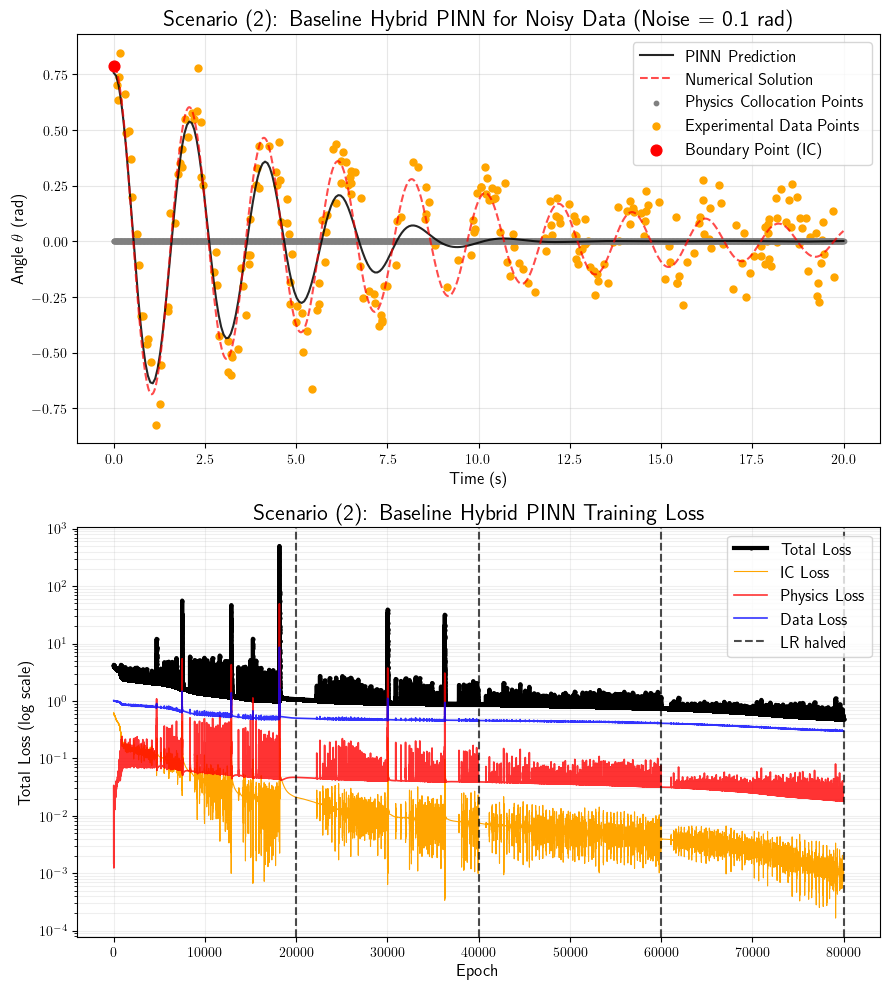

In [16]:
# Evaluate baseline PINN with noisy data over test points
# Pass physical time directly (FourierFeatureNN normalizes internally)
t_pred_noisy_data = torch.linspace(
    t_start, t_end, 300, device=device).view(-1, 1)

t_pred_norm_noisy_data = normalize_time_input(t_pred_noisy_data)

with torch.no_grad():
    theta_pred_norm_noisy_data = baseline_pinn_noisy_data(
        t_pred_norm_noisy_data)
    theta_pred_noisy_data      = denormalize_theta(
        theta_pred_norm_noisy_data,
        theta_mean_noisy,
        theta_std_noisy)

# Convert to NumPy for plotting
t_pred_np_noisy = t_pred_noisy_data[:, 0].detach().cpu().numpy()
theta_pred_np_noisy = theta_pred_noisy_data[:, 0].detach().cpu().numpy()

# Use the original t_phys for plotting collocation points
t_phys_np_noisy_data = t_phys_noisy_data[:, 0].detach().cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(9, 10))

# ----------------------------------------------------------------------------
# Plot 1: PINN prediction vs numerical solution
ax1 = axes[0]

ax1.plot(
    t_pred_np_noisy,
    theta_pred_np_noisy,
    color='black',
    label='PINN Prediction',
    alpha=0.85,
    zorder=4)

ax1.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7,
    zorder=4)

ax1.scatter(
    t_phys_np_noisy_data,
    np.zeros_like(t_phys_np_noisy_data),
    color='gray',
    s=10,
    label='Physics Collocation Points',
    zorder=3)

ax1.scatter(
    t_exp_np_noisy,
    theta_exp_np_noisy,
    color='orange',
    s=25,
    label='Experimental Data Points',
    zorder=2)

ax1.scatter(
    [0], [theta0_ground_truth],
    color='red', s=60,
    zorder=5,
    label='Boundary Point (IC)')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel(r'Angle $\theta$ (rad)', fontsize=12)
ax1.set_title(
    r"Scenario (2): Baseline Hybrid PINN for Noisy Data " 
    + rf"(Noise = {exp_noise_noisy_data} rad)", fontsize=16)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Plot 2: Training Loss
ax2 = axes[1]
ax2.plot(
    total_loss_history_noisy_data,
    marker='o',
    markersize=2,
    color='black',
    linewidth=3,
    label="Total Loss")
ax2.plot(
    ic_loss_history_noisy_data,
    color='orange',
    linewidth=0.8,
    label="IC Loss")
ax2.plot(
    physics_loss_history_noisy_data,
    color='red',
    linewidth=1.2,
    alpha=0.8,
    label="Physics Loss")
ax2.plot(
    data_loss_history_noisy_data,
    color='blue',
    linewidth=1.2,
    alpha=0.8,
    label="Data Loss")

# Add vertical lines to indicate learning rate halving points
for ep in range(20000, epochs_noisy_data + 1, 20000):
    ax2.axvline(
        x=ep,
        color='black',
        linestyle='--',
        alpha=0.7,
        label='LR halved' if ep == 20000 else None)


ax2.set_yscale('log')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Total Loss (log scale)', fontsize=12)
ax2.set_title(
    r"Scenario (2): Baseline Hybrid PINN Training Loss", fontsize=16)
ax2.legend(fontsize=12)
ax2.grid(True, which='both', linestyle='-', alpha=0.2)
plt.tight_layout()
plt.show()

# Different scenarios simulations

In this study, we test the hybrid PINN solutions across four different scenarios using different data points, time ranges, and simulated noise amplitudes:

| Scenario | Description | Data points | Time range | Noise $\sigma$ (rad) | Challenge |
|:--------:|-------------|:-----------:|:----------:|:-------------------:|-----------|
| 1 | Clean experimental data | 250 | $[0, 20]$ s | 0.001 | Baseline: low-noise, dense measurements |
| 2 | Noisy experimental data | 250 | $[0, 20]$ s | 0.1 | High observation noise obscures the true signal |
| 3 | Sparse experimental data | 75 | $[0, 20]$ s | 0.001 | Few data points to constrain the solution |
| 4 | Extrapolation beyond training window | 75 | $[0, 10]$ s | 0.001 | PINN must predict $t \in [10, 20]$ s using physics alone |


**Note:** We only test the baseline PINN with Scenario 1 and Scenario 2, as the performance of the baseline PINN already deteriorates significantly under Scenario 2. 

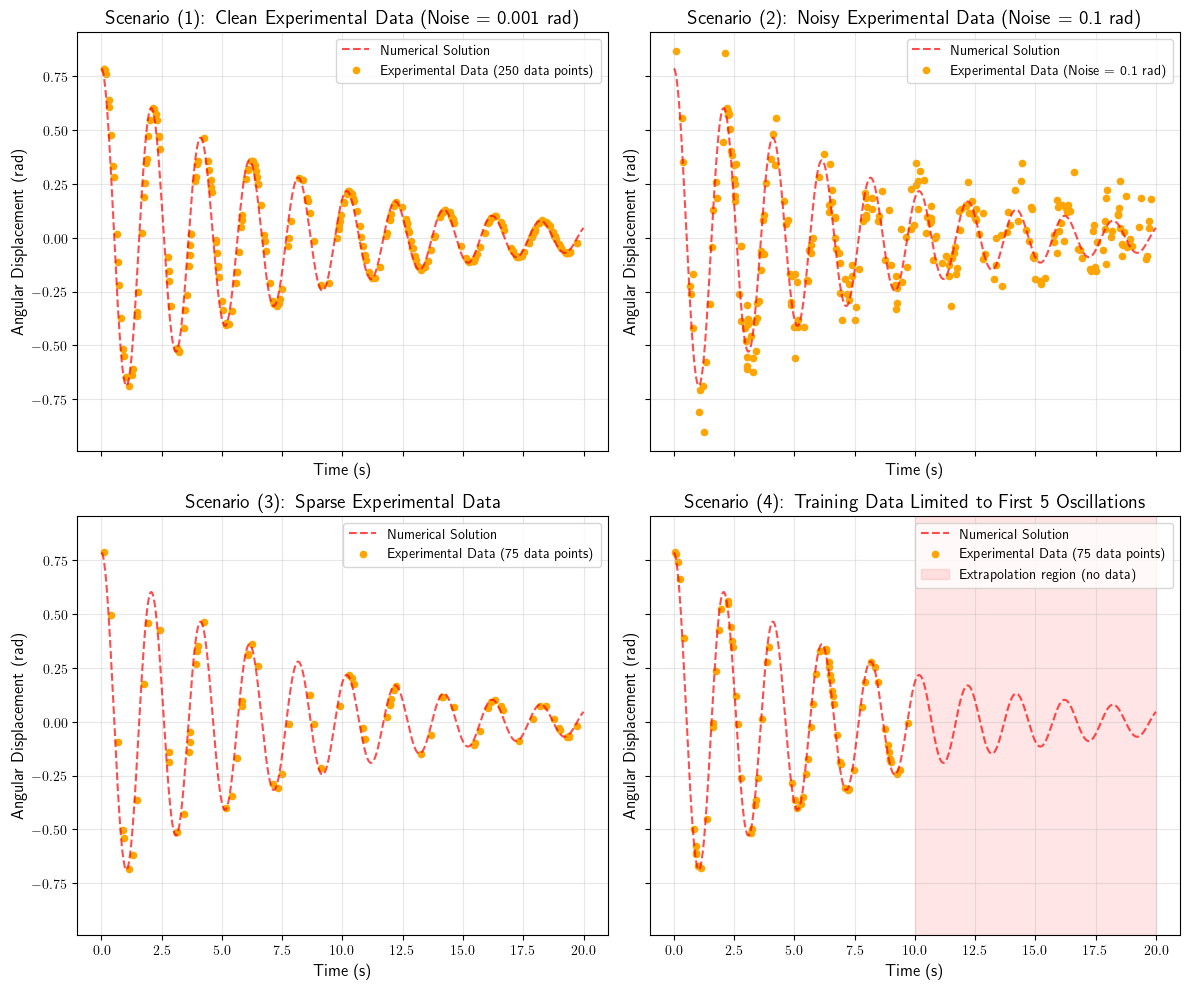

In [ ]:
np.random.seed(42)

# ----------------------------------------------------------------------------
# Scenario (1): Clean Experimental Data with Low Noise (0.001 rad)
# Generate 250 random time points uniformly in [t_start, t_end),
# using the shift-and-scale formula: rand() * (b - a) + a.
# np.sort arranges them in chronological order so the data
# looks like a realistic time series from a sensor.

N_exp_points_clean = 250

t_exp_np_clean_data     = np.sort(
    np.random.rand(N_exp_points_clean) * (t_end - t_start) + t_start)

# Simulate the pendulum system at these random time points to get the "true" 
# angular displacement values
solution_exp = odeint(
    pendulum_system,
    [theta0_ground_truth, omega0_ground_truth],
    t_exp_np_clean_data,
    args=(g, L, b, m))

# Noise standard deviation = 0.001 rad (small, realistic sensor noise)
# noise standard deviation (rad)
exp_noise_clean_data = 0.001

# Add realistic noise to the angular displacement data
theta_exp_np_clean_data = (
    solution_exp[:, 0] 
    + exp_noise_clean_data * np.random.randn(N_exp_points_clean))

# ----------------------------------------------------------------------------
# Scenario (2): Noisy Experimental Data with Higher Noise (0.1 rad)

N_exp_points_noisy = 250

# Generate 250 random time points uniformly in [t_start, t_end),
t_exp_np_noisy_data     = np.sort(
    np.random.rand(N_exp_points_noisy) * (t_end - t_start) + t_start)

# Simulate the pendulum system at these random time points to get the "true" 
# angular displacement values
solution_exp = odeint(
    pendulum_system,
    [theta0_ground_truth, omega0_ground_truth],
    t_exp_np_noisy_data,
    args=(g, L, b, m))


# Increase noise from 0.001 rad to 0.05 rad for a more challenging scenario
exp_noise_noisy_data = 0.1

# Add realistic noise to the angular displacement data
theta_exp_np_noisy_data = (
    solution_exp[:, 0] 
    + exp_noise_noisy_data * np.random.randn(N_exp_points_noisy))

# ----------------------------------------------------------------------------
# Scenario (3): Sparse Experimental Data with Only 75 Data Points

# Reduce the experimental data points to 75 to simulate a sparser 
# dataset, which is more realistic in many experimental scenarios.
N_exp_points_sparse = 75

np.random.seed(42)

# Generate 75 random time points uniformly in [t_start, t_end),
t_exp_np_sparse     = np.sort(
    np.random.rand(N_exp_points_sparse) * (t_end - t_start) + t_start)

# Simulate the pendulum system at these random time points to get the "true" 
# angular displacement values
solution_exp = odeint(
    pendulum_system,
    [theta0_ground_truth, omega0_ground_truth],
    t_exp_np_sparse,
    args=(g, L, b, m))

# Noise standard deviation = 0.001 rad (small, realistic sensor noise)
# noise standard deviation (rad)
exp_noise_sparse = 0.001

# Add realistic noise to the angular displacement data
theta_exp_np_sparse = (
    solution_exp[:, 0] + exp_noise_sparse * np.random.randn(
        N_exp_points_sparse))

# ----------------------------------------------------------------------------
# Scenario (4): Extrapolation Test with Data Only in the First Half 
# of the Time Range

# Experimental data covers only the first 5 oscillations.
# Period T = 2π/ω_n ≈ 2.0 s  →  5 oscillations ≈ 10 s.
# The PINN must extrapolate from t = 10 s to t = 20 s using physics alone.
N_exp_points_extrapolate = 75
t_data_end   = 10.0          # data window: [0, 10] s

# Generate 75 random time points uniformly in [t_start, t_data_end)
t_exp_np_extrapolate = np.sort(
    np.random.rand(N_exp_points_extrapolate) * (
        t_data_end - t_start) + t_start)

# Simulate the pendulum system at these random time points to get the "true" 
# angular displacement values
solution_exp = odeint(
    pendulum_system,
    [theta0_ground_truth, omega0_ground_truth],
    t_exp_np_extrapolate,
    args=(g, L, b, m))

# Noise standard deviation = 0.001 rad (small, realistic sensor noise)
exp_noise_extrapolate = 0.001

# Add realistic noise to the angular displacement data
theta_exp_np_extrapolate = (
    solution_exp[:, 0] + exp_noise_extrapolate * np.random.randn(
        N_exp_points_extrapolate))

# ----------------------------------------------------------------------------
# Plot all scenarios together for comparison
fig, axes = plt.subplots(
    2,2,
    figsize=(12, 10),
    sharex=True,
    sharey=True)

# Plot 1: Clean Experimental Data with Low Noise (0.001 rad)
ax1 = axes[0, 0]
ax1.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)
ax1.scatter(
    t_exp_np_clean_data,
    theta_exp_np_clean_data,
    color='orange',
    s=20,
    label=f'Experimental Data ({N_exp_points_clean} data points)')

ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax1.set_title(
    "Scenario (1): Clean Experimental Data " 
    + rf"(Noise = {exp_noise_clean_data} rad)",
    fontsize=14)
ax1.legend(
    fontsize=10,
    loc='upper right')
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Plot 2: Noisy Experimental Data with Higher Noise (0.1 rad)
ax2 = axes[0, 1]
ax2.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)
ax2.scatter(
    t_exp_np_noisy_data,
    theta_exp_np_noisy_data,
    color='orange',
    s=20,
    label=fr'Experimental Data (Noise = {exp_noise_noisy_data} rad)')

ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax2.set_title(
    "Scenario (2): Noisy Experimental Data "
    + rf"(Noise = {exp_noise_noisy_data} rad)",
    fontsize=14)
ax2.legend(
    fontsize=10,
    loc='upper right')
ax2.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Plot 3: Sparse Experimental Data with Only 75 Data Points
ax3 = axes[1, 0]
ax3.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)
ax3.scatter(
    t_exp_np_sparse,
    theta_exp_np_sparse,
    color='orange',
    s=20,
    label=f'Experimental Data ({N_exp_points_sparse} data points)')

ax3.set_xlabel('Time (s)', fontsize=12)
ax3.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax3.set_title(
    'Scenario (3): Sparse Experimental Data',
    fontsize=14)
ax3.legend(
    fontsize=10,
    loc='upper right')
ax3.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
ax4 = axes[1, 1]
ax4.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)
ax4.scatter(
    t_exp_np_extrapolate,
    theta_exp_np_extrapolate,
    color='orange',
    s=20,
    label=f'Experimental Data ({N_exp_points_extrapolate} data points)')

# Shade the extrapolation region
ax4.axvspan(t_data_end, t_end, alpha=0.10, color='red',
            label='Extrapolation region (no data)')

ax4.set_xlabel('Time (s)', fontsize=12)
ax4.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax4.set_title(
    'Scenario (4): Training Data Limited to First 5 Oscillations',
    fontsize=14)
ax4.legend(
    fontsize=10,
    loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

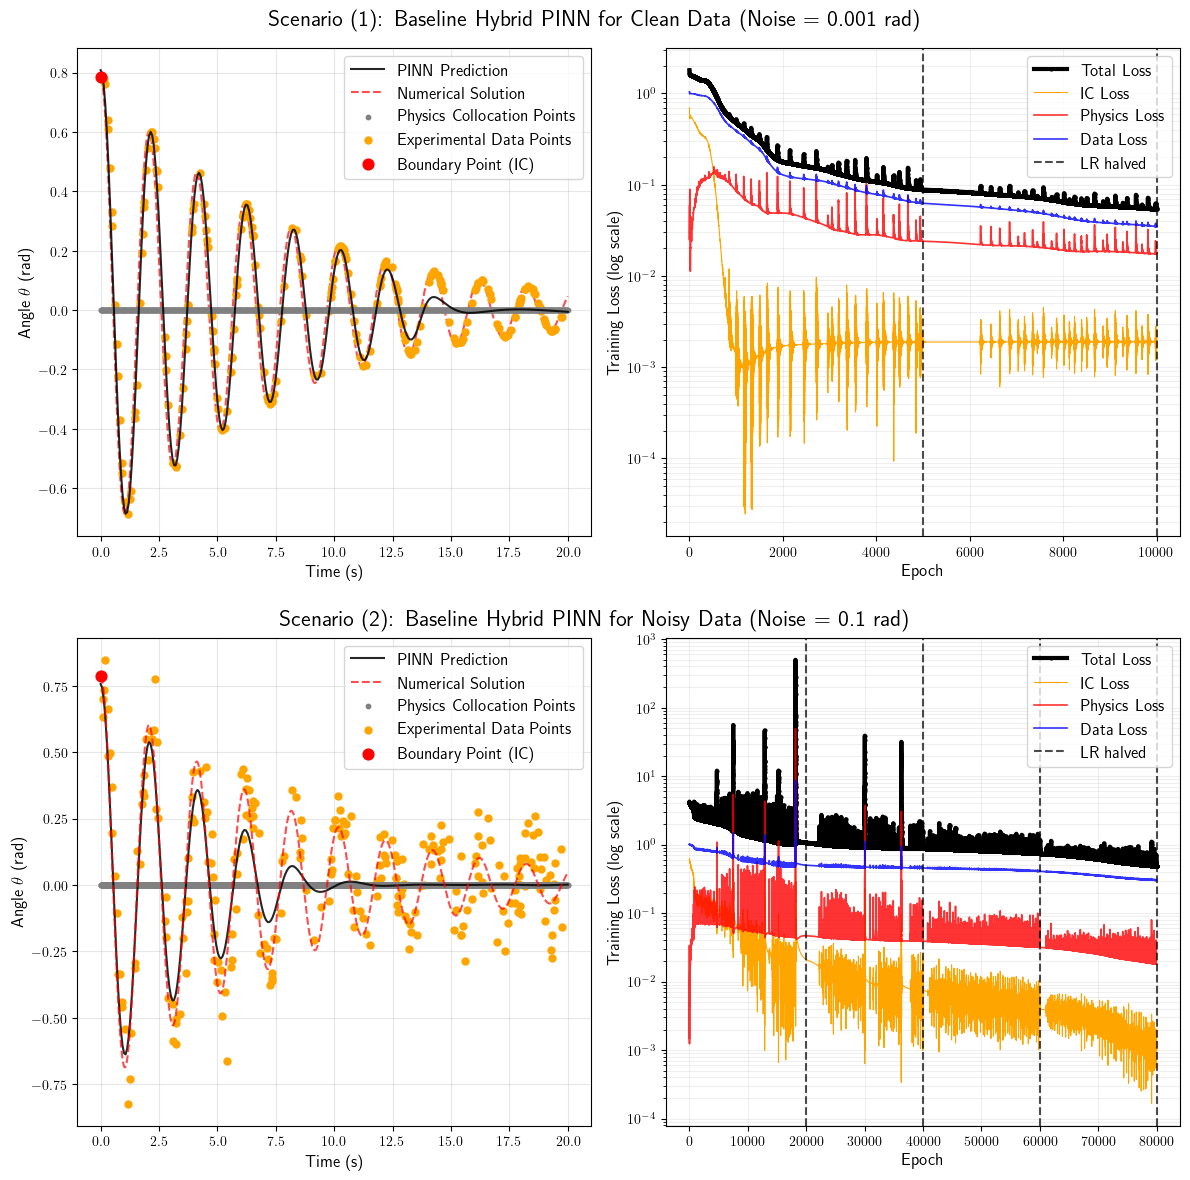

In [18]:
# ----------------------------------------------------------------------------
# Scenario (1): Baseline Hybrid PINN for Clean Data
# Evaluate PINN over test points
t_pred_clean_data      = torch.linspace(
    t_start, t_end, 300, device=device).view(-1, 1)
t_pred_norm_clean_data = normalize_time_input(t_pred_clean_data)

# Use torch.no_grad() to avoid tracking gradients during inference, 
# since we only want the predicted values and not the gradients here.
with torch.no_grad():
    theta_pred_norm_clean_data = baseline_pinn(t_pred_norm_clean_data)
    theta_pred_clean_data      = denormalize_theta(
        theta_pred_norm_clean_data,
        theta_mean_clean_data,
        theta_std_clean_data)

# Convert to NumPy for plotting
t_pred_np_clean_data = t_pred_clean_data[:, 0].detach().cpu().numpy()
theta_pred_np_clean_data = theta_pred_clean_data[:, 0].detach().cpu().numpy()

# Use the original t_phys for plotting collocation points
t_phys_np_clean_data = t_phys_clean_data[:, 0].detach().cpu().numpy()

# ----------------------------------------------------------------------------
# Scenario (2): Baseline Hybrid PINN for Noisy Data

# Evaluate baseline PINN with noisy data over test points
t_pred_noisy = torch.linspace(t_start, t_end, 300, device=device).view(-1, 1)
t_pred_norm_noisy = normalize_time_input(t_pred_noisy)

with torch.no_grad():
    theta_pred_norm_noisy = baseline_pinn_noisy_data(t_pred_norm_noisy)
    theta_pred_noisy      = denormalize_theta(
        theta_pred_norm_noisy,
        theta_mean_noisy,
        theta_std_noisy)

# Convert to NumPy for plotting
t_pred_np_noisy     = t_pred_noisy[:, 0].detach().cpu().numpy()
theta_pred_np_noisy = theta_pred_noisy[:, 0].detach().cpu().numpy()

# Use the original t_phys for plotting collocation points
t_phys_np_noisy_data = t_phys_noisy_data[:, 0].detach().cpu().numpy()

# ----------------------------------------------------------------------------
# Plot all scenarios together for comparison
# Plot 1: PINN prediction vs numerical solution
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 12))

fig.subplots_adjust(hspace=0.4)

# Shared title for Scenario (1), spans ax1 and ax2 (top row)
fig.text(
    0.5, 0.98,
    "Scenario (1): Baseline Hybrid PINN for Clean Data " 
    rf"(Noise = {exp_noise_clean_data} rad)",
    ha='center', va='top', fontsize=16)

ax1 = axes[0, 0]

# Plot the PINN prediction
ax1.plot(
    t_pred_np_clean_data,
    theta_pred_np_clean_data,
    color='black',
    label='PINN Prediction',
    alpha=0.85,
    zorder=4)

# Plot the original numerical solution for reference
ax1.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)

# Plot the physics collocation points and experimental data points
# Use the original t_phys tensor to get the collocation points, and 
# convert to NumPy for plotting
t_phys_np_clean_data = t_phys_clean_data[:, 0].detach().cpu().numpy()

ax1.scatter(
    t_phys_np_clean_data,
    np.zeros_like(t_phys_np_clean_data),
    color='gray',
    s=10,
    label='Physics Collocation Points',
    zorder=3)

# Plot the experimental data points (with noise)
ax1.scatter(
    t_exp_np_clean_data,
    theta_exp_np_clean_data,
    color='orange',
    s=25,
    label='Experimental Data Points',
    zorder=2)

# Plot the boundary point (initial condition)
ax1.scatter(
    [0], [theta0_ground_truth],
    color='red', s=60,
    zorder=5,
    label='Boundary Point (IC)')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel(r'Angle $\theta$ (rad)', fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Plot 2: Training Loss
ax2 = axes[0, 1]
ax2.plot(
    total_loss_history_clean_data,
    marker='o',
    markersize=2,
    color='black',
    linewidth=3,
    label="Total Loss"
    )
ax2.plot(
    ic_loss_history_clean_data,
    color='orange',
    linewidth=0.8,
    label="IC Loss")
ax2.plot(
    physics_loss_history_clean_data,
    color='red',
    linewidth=1.2,
    alpha=0.8,
    label="Physics Loss")
ax2.plot(
    data_loss_history_clean_data,
    color='blue',
    linewidth=1.2,
    alpha=0.8,
    label="Data Loss")

# Add vertical lines to indicate learning rate halving points
for ep in range(5000, epochs_clean_data + 1, 5000):
    ax2.axvline(
        x=ep,
        color='black',
        linestyle='--',
        alpha=0.7,
        label='LR halved' if ep == 5000 else None)

ax2.set_yscale('log')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Training Loss (log scale)', fontsize=12)
ax2.legend(fontsize=12)
ax2.grid(True, which='both', linestyle='-', alpha=0.2)

# ----------------------------------------------------------------------------
# Plot 1: PINN prediction vs numerical solution
ax3 = axes[1, 0]

ax3.plot(
    t_pred_np_noisy,
    theta_pred_np_noisy,
    color='black',
    label='PINN Prediction',
    alpha=0.85,
    zorder=4)

ax3.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7,
    zorder=4)

ax3.scatter(
    t_phys_np_noisy_data,
    np.zeros_like(t_phys_np_noisy_data),
    color='gray',
    s=10,
    label='Physics Collocation Points',
    zorder=3)

ax3.scatter(
    t_exp_np_noisy,
    theta_exp_np_noisy,
    color='orange',
    s=25,
    label='Experimental Data Points',
    zorder=2)

ax3.scatter(
    [0], [theta0_ground_truth],
    color='red', s=60,
    zorder=5,
    label='Boundary Point (IC)')
ax3.set_xlabel('Time (s)', fontsize=12)
ax3.set_ylabel(r'Angle $\theta$ (rad)', fontsize=12)
ax3.legend(fontsize=12)
ax3.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Plot 2: Training Loss
ax4 = axes[1, 1]
ax4.plot(
    total_loss_history_noisy_data,
    marker='o',
    markersize=2,
    color='black',
    linewidth=3,
    label="Total Loss")
ax4.plot(
    ic_loss_history_noisy_data,
    color='orange',
    linewidth=0.8,
    label="IC Loss")
ax4.plot(
    physics_loss_history_noisy_data,
    color='red',
    linewidth=1.2,
    alpha=0.8,
    label="Physics Loss")
ax4.plot(
    data_loss_history_noisy_data,
    color='blue',
    linewidth=1.2,
    alpha=0.8,
    label="Data Loss")

# Add vertical lines to indicate learning rate halving points
for ep in range(20000, epochs_noisy_data + 1, 20000):
    ax4.axvline(
        x=ep,
        color='black',
        linestyle='--',
        alpha=0.7,
        label='LR halved' if ep == 20000 else None)

# Shared title for Scenario (2), spans ax3 and ax4 (bottom row)
fig.text(
    0.5, 0.48,
    "Scenario (2): Baseline Hybrid PINN for Noisy Data " 
    rf"(Noise = {exp_noise_noisy_data} rad)",
    ha='center', va='top', fontsize=16)

ax4.set_yscale('log')
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Training Loss (log scale)', fontsize=12)
ax4.legend(fontsize=12)
ax4.grid(True, which='both', linestyle='-', alpha=0.2)
plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=4.0)

plt.savefig(
    "figures/baseline_hybrid_pinn_predictions_and_training_loss.png",
    dpi=600,
    bbox_inches='tight')
plt.show()

## Why the Baseline PINN Struggles

The comparison plot above reveals that the baseline fully connected PINN fails to accurately reproduce the damped pendulum dynamics in both scenarios:

**Scenario (1) Clean data ($\sigma = 0.001$ rad):** Even with near-perfect experimental observations, the PINN prediction begins to drift from the numerical solution after the first few oscillations. The network captures the initial transient well but progressively loses phase accuracy at later times. This is a direct consequence of **spectral bias**: the $\tanh$-activated network preferentially learns low-frequency components of the solution and struggles to maintain the higher-frequency oscillatory structure over the full 20 s window. Because the ODE residual must be satisfied simultaneously across the entire domain, errors at early times propagate and compound, causing the late-time prediction to degrade.

**Scenario (2) Noisy data ($\sigma = 0.1$ rad):** The failure is more severe. The PINN prediction diverges significantly from the true solution, with the network unable to resolve the oscillations beyond the first few cycles. The 100× larger noise creates conflicting gradients between the data loss (which tries to fit noisy points) and the physics loss (which enforces the smooth ODE). Without any mechanism to distinguish signal from noise, the optimizer is pulled in competing directions, leading to slow convergence and a poor final solution, as reflected by the erratic, high-magnitude training loss that persists even after 80,000 epochs.

::: {.callout-important}
## Key Limitations of the Baseline Architecture

1. **Spectral bias**: $\tanh$ networks learn low-frequency trends first and require disproportionately many epochs to capture higher harmonics, making long-time oscillatory solutions inherently difficult.
2. **No causal structure**: The physics loss treats all collocation points equally, so the network has no incentive to solve the ODE sequentially from the initial condition forward. Errors at $t = 0$ are not corrected before the network attempts to fit $t = 15$ s.
3. **No noise-aware weighting**: The data loss weights all experimental points equally, regardless of signal-to-noise ratio. Late-time data, where the true amplitude has decayed to near zero but the noise remains at $\sigma = 0.1$ rad, dominates the data gradient and actively misleads the network.

These structural shortcomings motivate the introduction of **Fourier feature embeddings** (to overcome spectral bias) and **curriculum training** (to impose causal learning order) in the next notebook.
:::

# References

1. Raissi, Maziar, Paris Perdikaris, and George E. Karniadakis. "Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations." Journal of Computational physics 378 (2019): 686-707. [10.1016/j.jcp.2018.10.045](https://www.sciencedirect.com/science/article/pii/S0021999118307125?via%3Dihub)

2. Wang, Sifan, Shyam Sankaran, Hanwen Wang, and Paris Perdikaris. "An expert's guide to training physics-informed neural networks." arXiv preprint arXiv:2308.08468 (2023). [https://doi.org/10.48550/arXiv.2308.08468](https://arxiv.org/abs/2308.08468)

3. Francis Fernandes (2026). [Mastering Dynamics PINNs](https://topmate.io/pinnsformechanicalengineers).

4. Dao, Duc Long. "Experimental evaluation of damping models for a nonlinear pendulum system." Physics Education 58, no. 5 (2023): 055003. [10.1088/1361-6552/ace1ca](https://iopscience.iop.org/article/10.1088/1361-6552/ace1ca/pdf)